<a href="https://colab.research.google.com/github/vinayprabhu/DAMP/blob/main/notebooks/3b_MARLYS_COMPARISONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Goal

The goal of this notebook is to

In [15]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

from scipy.linalg import block_diag
# Don't do linear algebra in Python without these two lines
np.set_printoptions(suppress=True)
from collections import Counter
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

%precision 3
#############################################
import sys
import importlib
importlib.reload(sys)
#######################
from google.colab import drive
drive.flush_and_unmount()
import os
drive.mount('/gdrive', force_remount=True)
project_dir="/gdrive/MyDrive/AMR/DAMP"
os.chdir(project_dir)

/tmp/ipykernel_7148/1255572125.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


Mounted at /gdrive


In [16]:
df_damp=pd.read_csv('./data_damp/df_damp_190973x4.tsv',sep='\t')
df_damp.shape

(190973, 4)

In [17]:
# url_marlys='https://data.mendeley.com/public-files/datasets/w4hb5grjwb/files/6c831932-8e0f-4441-9e53-33fae57da262/file_downloaded'
# !wget $url_marlys -O ./data_damp/MLAMP_db.json

In [18]:
df_marlys = pd.read_json('./data_damp/MLAMP_db.json')
df_marlys = df_marlys[['id', 'sequence']]
df_marlys = df_marlys.drop_duplicates(subset=['sequence'], keep='first')
print(df_marlys.shape)
df_marlys.head()

(103143, 2)


,id,sequence
0,MLAMP0000001,HSDAVFTDNYTRLRKQMAVKKYLNSILN
1,MLAMP0000002,GRLLRLLLRLLRG
2,MLAMP0000003,GNNRPVYIPQPRPPHPRL
3,MLAMP0000004,GLLKRIKTLLPINLKALAALAKKIL
4,MLAMP0000005,RLLKGLCKSIMKKFLRTI


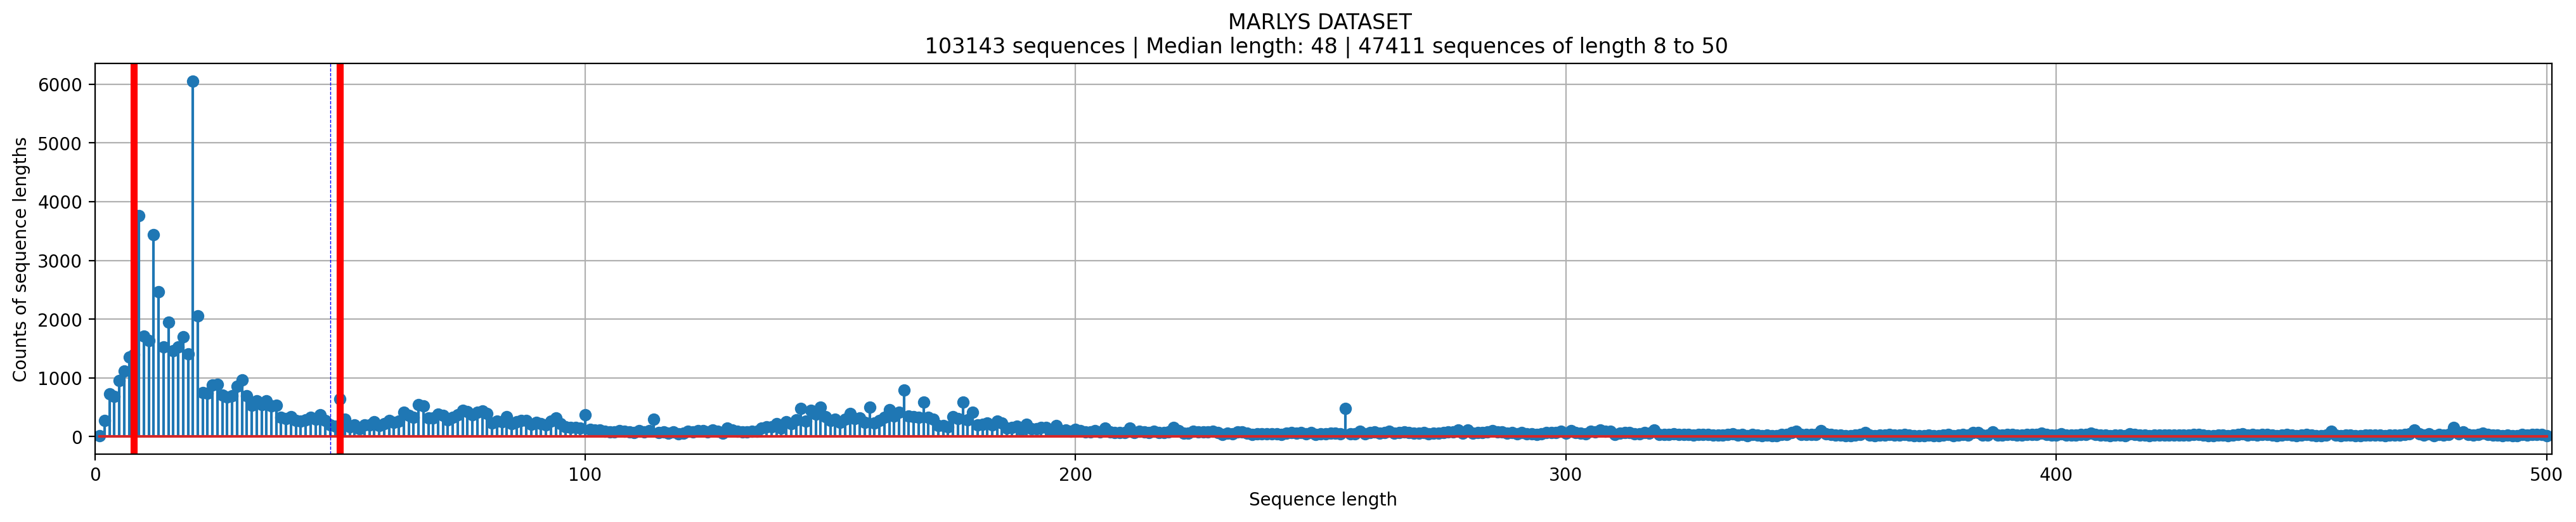

In [19]:
import matplotlib.pyplot as plt
lengths = df_marlys.sequence.apply(len).value_counts().sort_index()
df_marlys['len_seq']=df_marlys.sequence.apply(len)
plt.figure(figsize=(25,4))
plt.stem(lengths.index, lengths.values)
plt.xlim([0,df_marlys.len_seq.max()+1])
plt.grid('On')
plt.title(f'MARLYS DATASET \n {df_marlys.sequence.nunique()} sequences | Median length: {int(df_marlys.len_seq.median())} | {((df_marlys.len_seq<51)&(df_marlys.len_seq>7)).sum()} sequences of length 8 to 50');
plt.ylabel('Counts of sequence lengths')
plt.xlabel('Sequence length')
plt.axvline(x=int(df_marlys.len_seq.median()), color='blue', linestyle='--', linewidth=0.5)
plt.axvline(x=50, color='red', linestyle='-', linewidth=4)
plt.axvline(x=8, color='red', linestyle='-', linewidth=4)
plt.show()

In [20]:
df_neurips=pd.read_csv('./data_damp/df_neurips_fasta.tsv',sep='\t')
df_neurips.shape

(39448, 3)

In [21]:
set_damp=set(df_damp.sequence.values)
set_marlys=set(df_marlys.sequence.values)
set_neurips=set(df_neurips.Sequence.values)

/usr/local/lib/python3.13/dist-packages/matplotlib_venn/layout/venn3/pairwise.py:169: UserWarning: Bad circle positioning.
  warnings.warn("Bad circle positioning.")


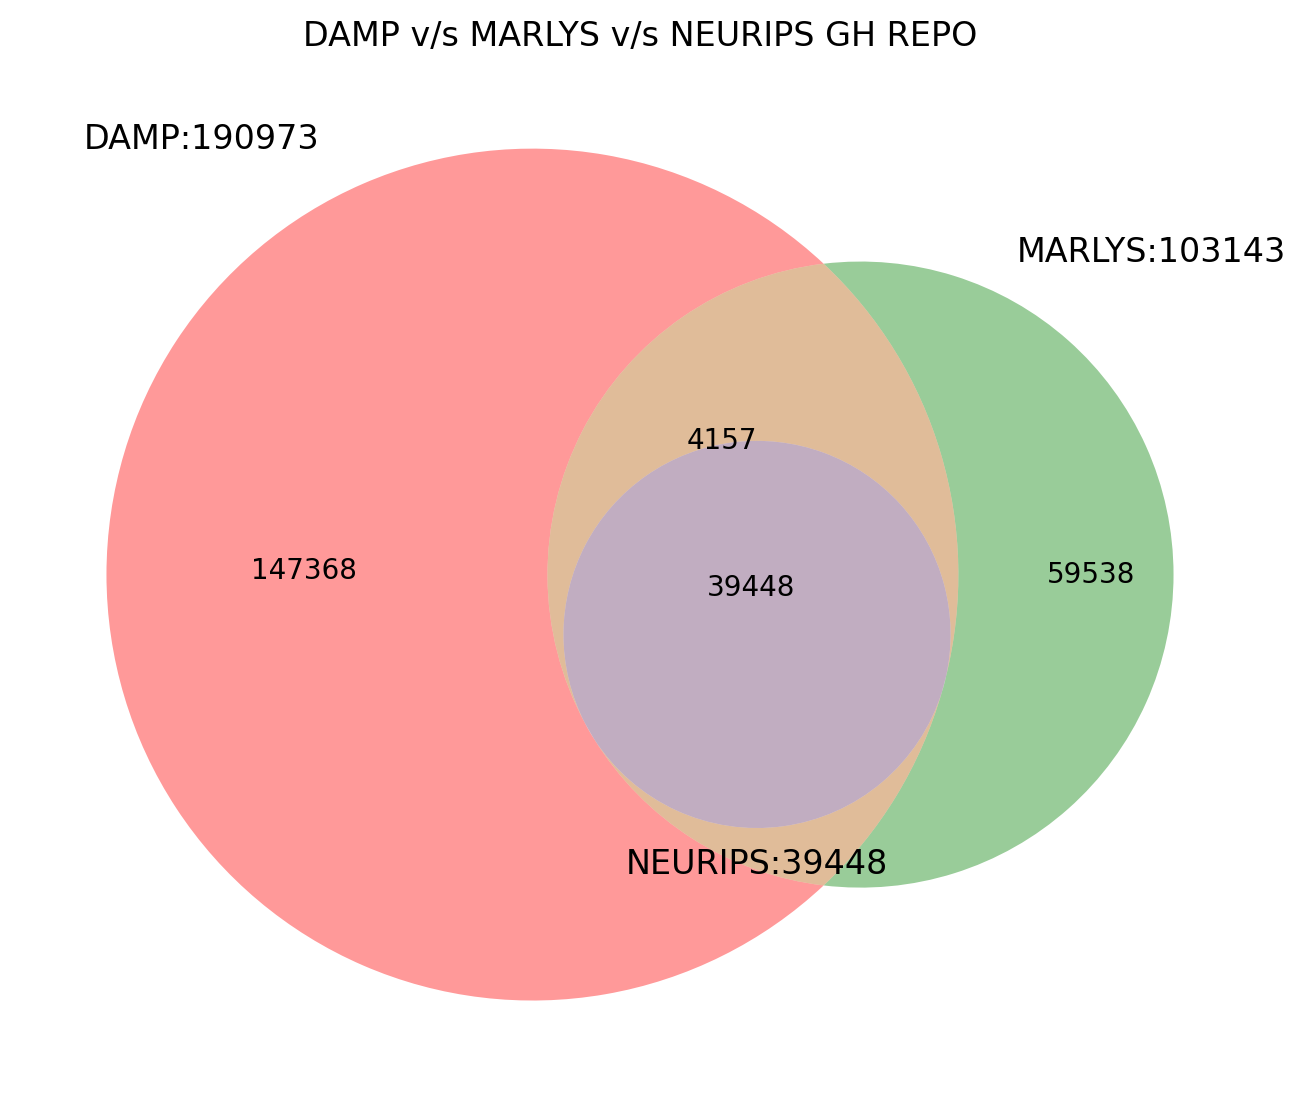

In [22]:
from matplotlib_venn import venn3
plt.figure(figsize=(8, 8))
venn3([set_damp, set_marlys, set_neurips], (f'DAMP:{len(set_damp)}', f'MARLYS:{len(set_marlys)}', f'NEURIPS:{len(set_neurips)}'))
plt.title("DAMP v/s MARLYS v/s NEURIPS GH REPO")
plt.show()

In [23]:
df_diff=pd.DataFrame(set_marlys.difference(set_damp))
df_diff.columns=['sequence']
df_diff['len_seq']=df_diff.sequence.apply(len)
df_marlys_novel=df_diff.loc[(df_diff.len_seq<51)&(df_diff.len_seq>7)].reset_index(inplace=False,drop=True)
df_marlys_novel

,sequence,len_seq
0,GIKIPCGESCAWVDFCFTSIVGCSCENKVCYKN,33
1,TCHCRRSCYSTEYSYGTCTVMGINHRFCCL,30
2,SATCCNYPPCYETYPESCL,19
3,AANAKLFDVRQSCCSAPLCALLYRVMCG,28
4,TPPAGPDGGPP,11
...,...,...
4647,LSGRVLFPLSCIGSSGFCFPFRCPHNREEIGRCFFPIQ,38
4648,MEKVLDLDVQVKGNNNTNDSAGDERVTSHFLCSYGCGNTGSFNSFCC,47
4649,HGLGHGHEQQHGLGHGHKFKLDDDLEHQGGHVLD,34
4650,HGPDSCNHEGGLCRVGNCIPGEYLAKYCFEPVILCCKSPSTTTAKS,46


In [24]:
df_marlys_append=pd.DataFrame(columns=df_damp.columns)
df_marlys_append['sequence']=df_marlys_novel.sequence.values
df_marlys_append['source']='marlys_8to50_novel'
df_marlys_append['model']='None'
df_marlys_append['paper']='10.17632/w4hb5grjwb.3'
df_marlys_append

,sequence,source,model,paper
0,GIKIPCGESCAWVDFCFTSIVGCSCENKVCYKN,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
1,TCHCRRSCYSTEYSYGTCTVMGINHRFCCL,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
2,SATCCNYPPCYETYPESCL,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
3,AANAKLFDVRQSCCSAPLCALLYRVMCG,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
4,TPPAGPDGGPP,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
...,...,...,...,...
4647,LSGRVLFPLSCIGSSGFCFPFRCPHNREEIGRCFFPIQ,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
4648,MEKVLDLDVQVKGNNNTNDSAGDERVTSHFLCSYGCGNTGSFNSFCC,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
4649,HGLGHGHEQQHGLGHGHKFKLDDDLEHQGGHVLD,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3
4650,HGPDSCNHEGGLCRVGNCIPGEYLAKYCFEPVILCCKSPSTTTAKS,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3


In [25]:
df_marlys_append.to_csv('./data_damp/df_marlys_append.tsv',sep='\t',index=False)

In [26]:
df_damp_new=pd.concat([df_damp,df_marlys_append],axis=0,ignore_index=True)
df_damp_new['len_seq']=df_damp_new.sequence.apply(len)
df_damp_new.to_csv(f'./data_damp/df_damp_{df_damp_new.shape[0]}x{df_damp_new.shape[1]}_new.tsv',sep='\t',index=False)

In [27]:
f'./data_damp/df_damp_{df_damp_new.shape[0]}x{df_damp_new.shape[1]}_new.tsv'

'./data_damp/df_damp_195625x5_new.tsv'

In [28]:
df_damp_new

,sequence,source,model,paper,len_seq
0,SINSLIIKLIQADILKNKLS,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x,20
1,MARNLVRYVQGLKKKKVI,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x,18
2,KWTKIYLPLLL,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x,11
3,NLVRYVQGLKKKKVIVIPVGIG,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x,22
4,EIKIYKKL,Extinctomics,APEX_1.0,https://doi.org/10.1038/s41551-024-01201-x,8
...,...,...,...,...,...
195620,LSGRVLFPLSCIGSSGFCFPFRCPHNREEIGRCFFPIQ,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3,38
195621,MEKVLDLDVQVKGNNNTNDSAGDERVTSHFLCSYGCGNTGSFNSFCC,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3,47
195622,HGLGHGHEQQHGLGHGHKFKLDDDLEHQGGHVLD,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3,34
195623,HGPDSCNHEGGLCRVGNCIPGEYLAKYCFEPVILCCKSPSTTTAKS,marlys_8to50_novel,None,10.17632/w4hb5grjwb.3,46
